# Reproducing the paper

Every number quoted in `paper/` is a macro, defined once in `paper/headline.tex` and filled in by a generator under `scripts/paper/`. This notebook shows how the whole paper is regenerated from `results/` by 1 script, what the coverage ledger tracks, how far the sweeps cover the declared basis, where a claim can be traced back to the file that produced it, which mistakes have already changed a published number and which checks now catch them, and what is still single-seed or still running. It reads `paper/headline.json`, `paper/tables/*.macros.json`, `results/coverage/coverage.json` and `results/detection_summary.csv`, runs on CPU and takes about 1 minute.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json
import logging
import warnings

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
# torchvision's ToTensor deprecation fires once per dataset load and says nothing
# about the numbers below.
warnings.filterwarnings("ignore", message="The transform `ToTensor", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import word_list

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline


def macro(table, name):
    """1 value of paper/tables/<table>.macros.json, the string headline.tex prints."""
    with open(f"paper/tables/{table}.macros.json") as handle:
        sidecar = json.load(handle)
    value = sidecar["macros"][name]["value"]
    return value


def show_diagram(name, width=None):
    """Embed a TikZ diagram rendered by notebooks/figures/render.py."""
    display(Image(filename=f"notebooks/figures/{name}.png", width=width))

from scripts.paper._common import clearing_cells, dataset_label, load_coverage, load_json
from scripts.paper._style import legend_above

## From checkpoints to the paper

The diagram is the pipeline every number crosses. Training writes a checkpoint with its `args.json`, `cli.sweep` writes the stage-1 cache on a GPU, `cli.analyze` turns it into `psbd_metrics.json` on a CPU, `cli.evaluate` writes ASR and clean accuracy, the coverage ledger classes every checkpoint, and the generators under `scripts/paper/` read the ledger and the metrics into tables and macro sidecars that `build_all.py` folds into `paper/headline.tex`.

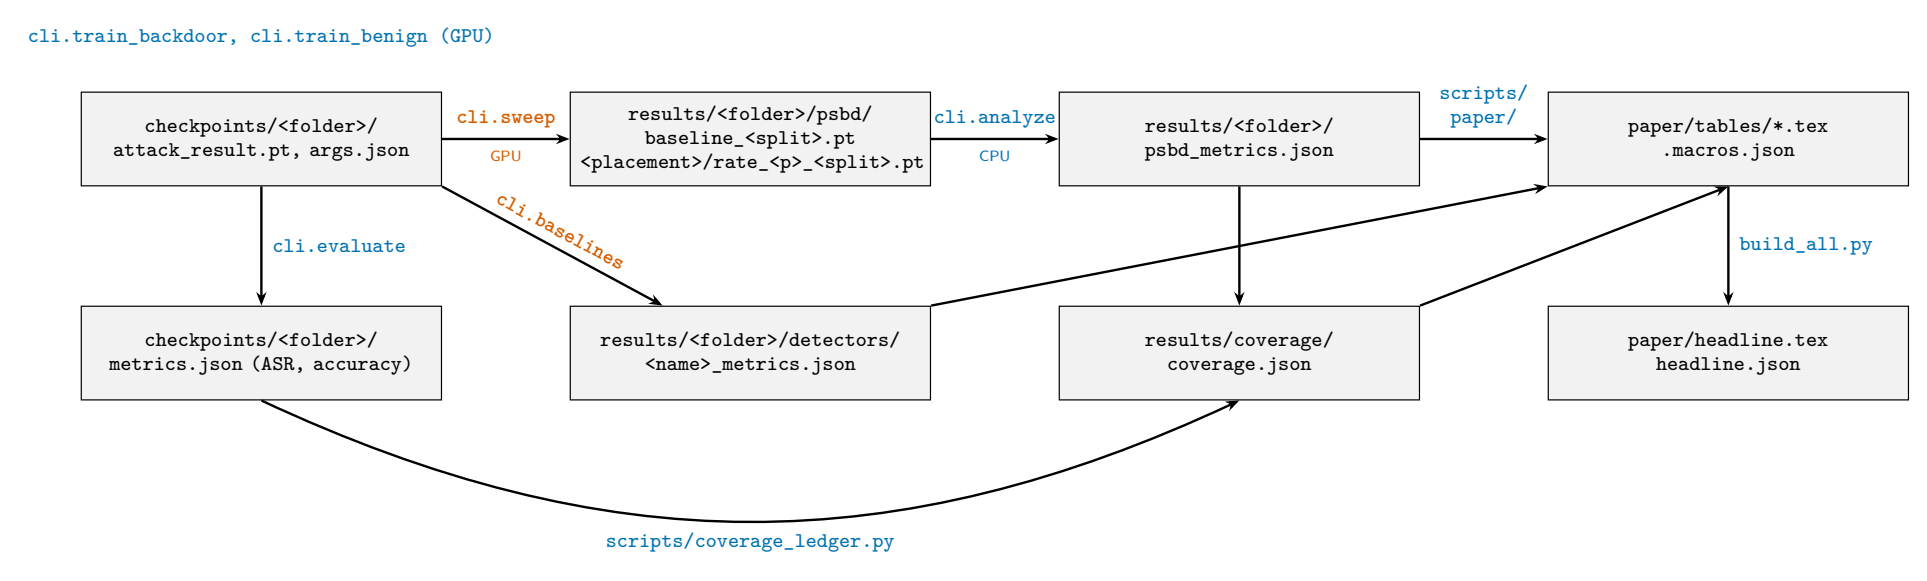

In [2]:
show_diagram("data_flow")

## The build script

```bash
PYTHONPATH=. python scripts/paper/build_all.py --results-dir results
```

`scripts/paper/build_all.py` runs every `tab_*.py`, `fig_*.py`, `app_*.py` and `mech_*.py` generator under `scripts/paper/`, folds their macro sidecars into `paper/headline.tex` and `paper/headline.json`, then runs every `ledger_*.py` script, which reads that folded headline back. Last, it reads every chapter under `paper/sections/` and fails the build on 2 things. The first is a digit outside a citation, a label, a reference or a macro. The second is a macro a chapter uses that `headline.tex` never defines. A chapter that passes this check quotes only numbers a script actually produced and none typed by hand. The figure counts the macros each generator contributes to the current `paper/headline.json`.

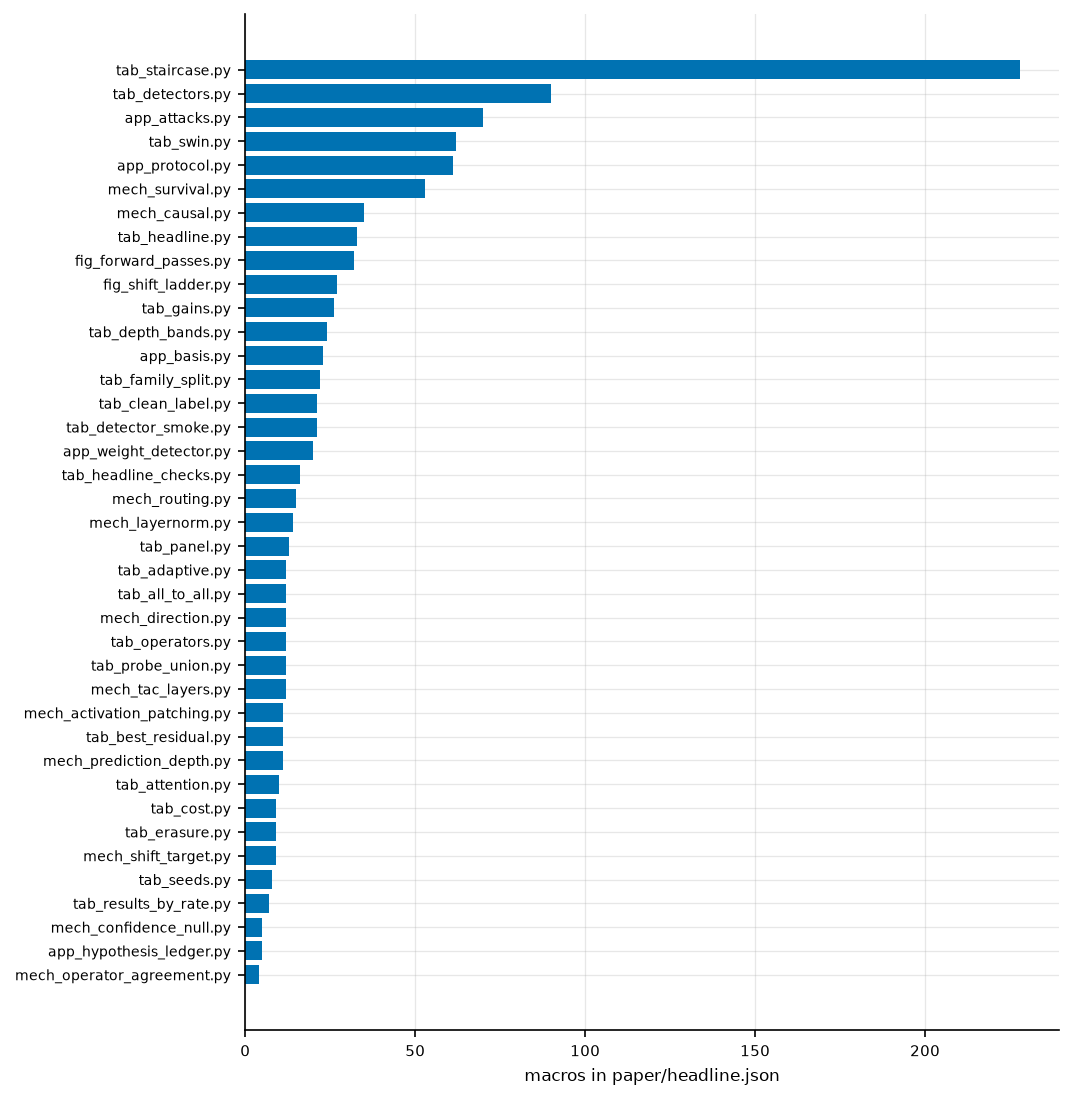

paper/headline.json defines 1077 macros from 39 generators
example: \HeadlineAurocAdaptive = 0.951, mean AUROC of the recommended placement at the adaptive rule, over the 56 cells carrying both compared placements
         generator scripts/paper/tab_headline.py, inputs ['results/coverage/coverage.json', 'results/<folder>/psbd_metrics.json (62 cells)']


In [3]:
macros = load_json("paper/headline.json")
by_generator = pd.Series([entry["generator"].removeprefix("scripts/paper/") for entry in macros.values()]).value_counts()

figure, axis = plt.subplots(figsize=(7.0, 0.2 * len(by_generator) + 1.0))
axis.barh(range(len(by_generator)), by_generator.values, color="#0072B2")
axis.set_yticks(range(len(by_generator)), labels=by_generator.index, fontsize=6.5)
axis.invert_yaxis()
axis.set_xlabel("macros in paper/headline.json")
plt.show()
print(f"paper/headline.json defines {len(macros)} macros from {len(by_generator)} generators")
sample = macros["HeadlineAurocAdaptive"]
print(f"example: \\HeadlineAurocAdaptive = {sample['value']}, {sample['meaning']}")
print(f"         generator {sample['generator']}, inputs {sample['inputs']}")

The staircase generator writes by far the most macros, 1 per row statistic of its 4 tables and the appendix generators for the attacks and the protocol follow. The count says nothing about which macros the chapters use, only which ones exist and the build fails on a used macro that is missing rather than on an unused one that exists.

## The coverage ledger

`results/coverage/coverage.json` is the single source of which models exist, which of them the attack implanted on and how much of the basis each carries. `scripts.paper._common.load_coverage` keeps the panel datasets. `asr_class == "clears"` marks a model whose ASR reaches the declared bar, the implantation count. A model whose clean accuracy fell below half the benign reference is `diverged`, and a TaCT model whose clean source class is already sent elsewhere is `source_mapped`, both excluded whatever their ASR reads. A model enters a detection table only if it is a successful backdoor, `successful_2pt`: it clears the ASR bar and keeps its clean accuracy within the headline bar of its benign reference. `scripts.paper._common.clearing_cells` returns exactly these, and `successful_5pt` is the looser bar every headline number is also given at.

ledger generated 2026-09-30T12:54:51+00:00, declaration configs/psbd_basis.json, basis of 27 placements
models in the panel ledger: 104
asr_class
clears           65
below_bar        30
source_mapped     8
diverged          1


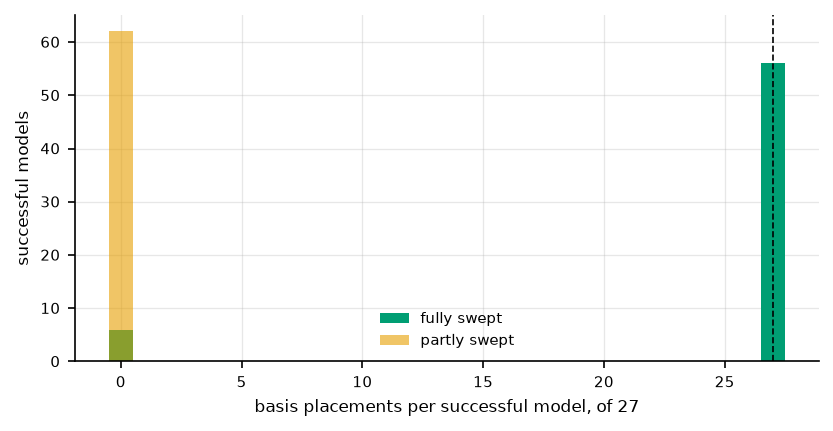

successful models with all 27 basis placements fully swept: 56 of 62


In [4]:
coverage = load_coverage("results")
ledger = pd.DataFrame(coverage["cells"])
by_class = ledger["asr_class"].value_counts()
assert str(len(ledger)) == macro("panel", "PanelCellsTotal")
assert str(by_class["clears"]) == macro("panel", "PanelCellsClearing")
assert str(int(ledger["successful_2pt"].sum())) == macro("panel", "PanelCellsSuccessful")
assert str(int(ledger["successful_5pt"].sum())) == macro("panel", "PanelCellsSuccessfulFivePoint")
assert str(by_class["source_mapped"]) == macro("panel", "PanelCellsSourceMapped")
print(f"ledger generated {coverage['generated_at']}, declaration {coverage['declaration']}, basis of {coverage['basis_size']} placements")
print(f"models in the panel ledger: {len(ledger)}")
print(by_class.to_string())

clearing = ledger[ledger["successful_2pt"].astype(bool)]
figure, axis = plt.subplots(figsize=(6.4, 3.0))
bins = np.arange(-0.5, coverage["basis_size"] + 1.5)
axis.hist(clearing["n_basis_covered"], bins=bins, color="#009E73", label="fully swept")
axis.hist(clearing["n_basis_partial"], bins=bins, color="#E69F00", alpha=0.6, label="partly swept")
axis.axvline(coverage["basis_size"], color="black", lw=0.8, ls="--")
axis.set_xlabel(f"basis placements per successful model, of {coverage['basis_size']}")
axis.set_ylabel("successful models")
axis.legend()
plt.show()
print(f"successful models with all {coverage['basis_size']} basis placements fully swept: "
      f"{int((clearing['n_basis_covered'] >= coverage['basis_size']).sum())} of {len(clearing)}")
fully_swept = int((clearing["n_basis_covered"] >= coverage["basis_size"]).sum())

In [5]:
display(Markdown(rf"""
The panel holds {len(ledger)} ViT-B/16 cells: {by_class["clears"]} clear the bar, {by_class["source_mapped"]} are source-mapped TaCT and {by_class.get("diverged", 0)} diverged. Of the {by_class["clears"]} that clear, {len(clearing)} are successful backdoors at the {macro("panel", "PanelCleanBarPoints")}-point clean-accuracy bar and {macro("panel", "PanelCellsSuccessfulFivePoint")} at the {macro("panel", "PanelCleanBarPointsSecond")}-point bar. The {macro("panel", "PanelCellsFailingCleanBar")} left out by the headline bar are {macro("panel", "PanelCellsFailingCleanBarNames").replace(chr(92) + "%", "%")}. These are the counts `start-here.ipynb` drew and the macros `\PanelCellsTotal`, `\PanelCellsClearing`, `\PanelCellsSuccessful` and `\PanelCellsSourceMapped` print. The histogram shows how much of the {coverage["basis_size"]}-placement basis each successful model carries. A placement is fully swept when every declared rate has all 3 splits on disk, and partly swept when some rates are missing. {fully_swept} of the {len(clearing)} carry every placement fully swept, and the rest are cells whose sweeps were still queued (below). Where a placement's ladder never reaches a rule's shift target the model has no reading for it, so every placement mean in the paper is averaged over the models it covers, which is why the tables print an n beside every mean and why cross-placement comparisons are always paired. The ledger's `gaps` list names every missing (model, placement, rate). The figure does not show which placements are missing where, which the `gaps` list and `results/coverage/COVERAGE.md` do.
"""))


The panel holds 104 ViT-B/16 cells: 65 clear the bar, 8 are source-mapped TaCT and 1 diverged. Of the 65 that clear, 62 are successful backdoors at the 2-point clean-accuracy bar and 64 at the 5-point bar. The 3 left out by the headline bar are SIG at 10% on CIFAR-10, WaNet at 5% on CIFAR-10 and WaNet at 10% on GTSRB. These are the counts `start-here.ipynb` drew and the macros `\PanelCellsTotal`, `\PanelCellsClearing`, `\PanelCellsSuccessful` and `\PanelCellsSourceMapped` print. The histogram shows how much of the 27-placement basis each successful model carries. A placement is fully swept when every declared rate has all 3 splits on disk, and partly swept when some rates are missing. 56 of the 62 carry every placement fully swept, and the rest are cells whose sweeps were still queued (below). Where a placement's ladder never reaches a rule's shift target the model has no reading for it, so every placement mean in the paper is averaged over the models it covers, which is why the tables print an n beside every mean and why cross-placement comparisons are always paired. The ledger's `gaps` list names every missing (model, placement, rate). The figure does not show which placements are missing where, which the `gaps` list and `results/coverage/COVERAGE.md` do.


## Kinds of mistakes this pipeline has already made

A generator that reads only from disk cannot invent a number, but it can still read the wrong file, mix 2 incompatible conventions, include models that are not what they seem or read a cache that outlived the run that wrote it. 4 examples follow, kept here because each changed a published number before it was caught.

**A comparison at unmatched disturbance.** An earlier draft compared 2 placements at whatever rate a script happened to pick for each, rather than at a matched clean-validation shift ratio. `docs/audit-2026-09-07.md` found that the withdrawn +0.258 headline for `gain_scale` at `mlp_norm_out` reproduced only under that single unmatched protocol, with absolute PSU at the nearest swept rate, and fell to a small, uncertain number under every protocol that reads both placements at the same disturbance. `PLACEMENT_MATCH_TARGET` in `defenses/decision.py` now names the single comparison device every cross-placement number uses. The cell below reads the current value of the same comparison off the staircase macros.

In [6]:
gain_scale_vs_tm = macro("staircase", "StaircaseOperatorsMlpNormOutGainScaleGain")
gain_scale_auroc = macro("staircase", "StaircaseOperatorsMlpNormOutGainScaleAuroc")
print("withdrawn claim: +0.258 AUROC for gain_scale at mlp_norm_out, unmatched rates, absolute PSU")
print(f"today, adaptive rule, fractional PSU, 57-model panel: gain_scale at mlp_norm_out reads {gain_scale_auroc}, "
      f"{gain_scale_vs_tm.replace('$-$', '-')} against PSBD-TM paired")
print("see docs/audit-2026-09-07.md for the full 4-protocol comparison")

withdrawn claim: +0.258 AUROC for gain_scale at mlp_norm_out, unmatched rates, absolute PSU
today, adaptive rule, fractional PSU, 57-model panel: gain_scale at mlp_norm_out reads 0.938, -0.013 against PSBD-TM paired
see docs/audit-2026-09-07.md for the full 4-protocol comparison


**A cache that outlived its data.** The sweep and the analysis are 2 separate stages, and a stage-2 record goes stale if the stage-1 cache behind it is regenerated with a different rate ladder or split. `evaluation.summary.load_detection_summary` drops every row of the pooled summary whose stage-1 tensors are gone, and `summary_coverage` shows the shape of what is left per architecture and dataset, so a coverage difference is visible before it becomes a conclusion.

detection summary: 24043 of 30378 rows kept, dropped 6335 variant, 0 not cache-backed


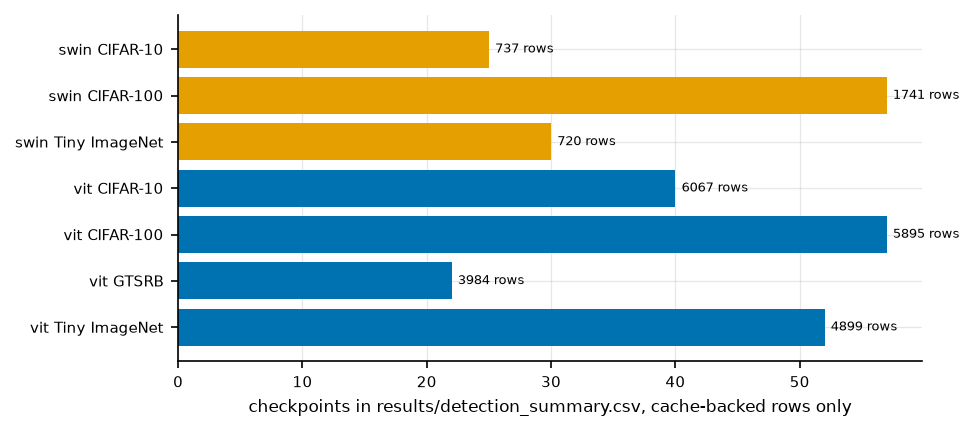

,architecture,dataset,checkpoints,cells
0,swin,cifar10,25,737
1,swin,cifar100,57,1741
2,swin,tiny,30,720
3,vit,cifar10,40,6067
4,vit,cifar100,57,5895
5,vit,gtsrb,22,3984
6,vit,tiny,52,4899


In [7]:
from evaluation.summary import load_detection_summary, summary_coverage

summary = load_detection_summary("results/detection_summary.csv")
coverage_check = summary_coverage(summary)
figure, axis = plt.subplots(figsize=(6.4, 3.0))
labels = [f"{a} {dataset_label(d)}" for a, d in zip(coverage_check["architecture"], coverage_check["dataset"])]
axis.barh(range(len(coverage_check)), coverage_check["checkpoints"], color=["#0072B2" if a == "vit" else "#E69F00" for a in coverage_check["architecture"]])
for position, cells_count in enumerate(coverage_check["cells"]):
    axis.text(coverage_check["checkpoints"].iloc[position] + 0.5, position, f"{cells_count} rows", va="center", fontsize=6)
axis.set_yticks(range(len(coverage_check)), labels=labels, fontsize=7)
axis.invert_yaxis()
axis.set_xlabel("checkpoints in results/detection_summary.csv, cache-backed rows only")
plt.show()
vit_cifar100_summary = int(coverage_check.loc[(coverage_check["architecture"] == "vit") & (coverage_check["dataset"] == "cifar100"), "checkpoints"].sum())
vit_cifar100_ledger = int((ledger["dataset"] == "cifar100").sum())
summary_swin_datasets = sorted(coverage_check.loc[coverage_check["architecture"] == "swin", "dataset"])
coverage_check

In [8]:
display(Markdown(rf"""
The pooled summary is a convenience table written by `cli.summary`, not a source the paper reads. It lags the per-model `psbd_metrics.json` files. Its counts include SAM, seed-replicate and evasion folders the panel leaves out ({vit_cifar100_summary} CIFAR-100 ViT checkpoints against {vit_cifar100_ledger} CIFAR-100 panel cells), and its Swin rows cover only {word_list([dataset_label(d) for d in summary_swin_datasets])}. The figure is here to show why the generators read the per-model files through the ledger instead of this table.
"""))


The pooled summary is a convenience table written by `cli.summary`, not a source the paper reads. It lags the per-model `psbd_metrics.json` files. Its counts include SAM, seed-replicate and evasion folders the panel leaves out (57 CIFAR-100 ViT checkpoints against 26 CIFAR-100 panel cells), and its Swin rows cover only CIFAR-10, CIFAR-100 and Tiny ImageNet. The figure is here to show why the generators read the per-model files through the ledger instead of this table.


**Models that are not the backdoor they claim.** Until 2026-09-24 the panel held 11 clearing TaCT models. `experiments/why_token_masking_works/` found that 8 of them misclassify their whole clean source class with no trigger present, so their ASR measures a class mapping. The ledger now marks them `source_mapped` and every panel number moved, the headline from 65 to 57 models. `data-and-attacks.ipynb` draws the evidence.

**A collapsed model with a plausible ASR.** A batch of GTSRB runs on the constant-rate recipe fell to a single class in their last epochs and saved with a plausible ASR. `training.loop.train_classifier` now refuses to write a checkpoint whose final validation accuracy is below half the run's best, and the ledger marks `diverged` any cell whose clean accuracy is below half the benign reference (`docs/runs/2026-09-11-diverged-gtsrb-runs.md`).

## What is still single-seed

Every headline number is read from a single training seed per checkpoint. `scripts/paper/tab_seeds.py` measures how much that matters on the clearing cells trained with extra seeds (`_seed_1`, `_seed_2`): the standard deviation of each placement's AUROC across seeds, averaged over cells, together with how often the paired gain changes sign between seeds.

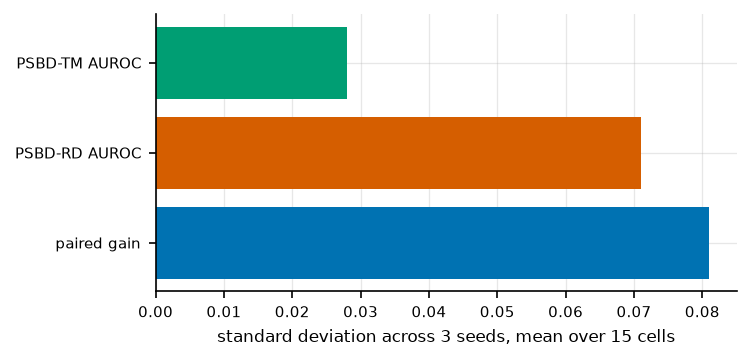

seed-averaged paired gain on these cells +0.106, sign flips across seeds on 4 of 15 cells, largest per-cell gain spread 0.259


In [9]:
seed_macros = {
    "PSBD-TM AUROC": float(macro("seeds", "SeedSdRecommended")),
    "PSBD-RD AUROC": float(macro("seeds", "SeedSdPublished")),
    "paired gain": float(macro("seeds", "SeedSdGain")),
}
figure, axis = plt.subplots(figsize=(5.0, 2.4))
axis.barh(list(seed_macros), list(seed_macros.values()), color=["#009E73", "#D55E00", "#0072B2"])
axis.invert_yaxis()
axis.set_xlabel(f"standard deviation across {macro('seeds', 'SeedsPerCell')} seeds, mean over {macro('seeds', 'SeedCells')} cells")
plt.show()
print(f"seed-averaged paired gain on these cells {macro('seeds', 'SeedGainMean')}, "
      f"sign flips across seeds on {macro('seeds', 'SeedGainSignFlips')} of {macro('seeds', 'SeedCells')} cells, "
      f"largest per-cell gain spread {macro('seeds', 'SeedSdGainMax')}")

In [10]:
display(Markdown(rf"""
PSBD-TM's AUROC moves by {macro("seeds", "SeedSdRecommended")} across seeds on average and PSBD-RD's by {macro("seeds", "SeedSdPublished")} (`\SeedSdRecommended`, `\SeedSdPublished`, over {macro("seeds", "SeedCells")} cells with {macro("seeds", "SeedsPerCell")} seeds each), so a single seed is a {"fairer reading of PSBD-TM than of PSBD-RD" if float(macro("seeds", "SeedSdRecommended")) < float(macro("seeds", "SeedSdPublished")) else "no fairer reading of PSBD-TM than of PSBD-RD"}, and the paired gain changes sign across seeds on {macro("seeds", "SeedGainSignFlips")} of the {macro("seeds", "SeedCells")} cells (`\SeedGainSignFlips`). The panel mean averages over many cells, which damps this, but a single cell's gain should not be read as settled. The Swin section reports only placements with at least `tab_swin.MIN_CELLS_FOR_ROW` models, a limit the paper states.
"""))


PSBD-TM's AUROC moves by 0.028 across seeds on average and PSBD-RD's by 0.071 (`\SeedSdRecommended`, `\SeedSdPublished`, over 15 cells with 3 seeds each), so a single seed is a fairer reading of PSBD-TM than of PSBD-RD, and the paired gain changes sign across seeds on 4 of the 15 cells (`\SeedGainSignFlips`). The panel mean averages over many cells, which damps this, but a single cell's gain should not be read as settled. The Swin section reports only placements with at least `tab_swin.MIN_CELLS_FOR_ROW` models, a limit the paper states.


## What is still running

On 2026-09-24 2 clearing cells were queued on GPU without their PSBD sweeps (`vit_gtsrb_tact_0_01_cos` and `vit_gtsrb_lc_0_05_tl1_adv`), and 6 multi-source TaCT retrains (`_src{k}` folders, `docs/runs/2026-09-24-tact-multisource.md`) were queued to replace the source-mapped models. The 2 clearing cells got their sweeps on 2026-09-30 and joined the headline panel. The cell lists the clearing cells missing from the headline panel as the ledger reads them now. When the jobs land, `scripts/coverage_ledger.py` and `build_all.py` are rerun. Every panel number moves with them, and so does every assert in these notebooks that checks one.

In [11]:
import glob

from scripts.paper.tab_staircase import panel_cells

panel = panel_cells("results", coverage)
panel_folders = {cell["folder_name"] for cell in panel}
missing = sorted(set(clearing["folder_name"]) - panel_folders)
print(f"{len(panel_folders)} of {len(clearing)} successful cells are in the headline panel")
print("successful cells outside it:", missing)
multi_source = sorted(path.split("/")[1] for path in glob.glob("checkpoints/vit_*_src*/args.json"))
print("multi-source TaCT checkpoints on disk:", multi_source or "none yet")

56 of 62 successful cells are in the headline panel
successful cells outside it: ['vit_cifar100_tact_0_01_src5', 'vit_cifar100_tact_0_05_src25', 'vit_cifar10_tact_0_1_src5', 'vit_gtsrb_tact_0_1_src12', 'vit_tiny_tact_0_01_src10', 'vit_tiny_tact_0_05_src50']
multi-source TaCT checkpoints on disk: ['vit_cifar100_tact_0_01_src5', 'vit_cifar100_tact_0_05_src25', 'vit_cifar10_tact_0_1_src5', 'vit_gtsrb_tact_0_1_src12', 'vit_tiny_tact_0_01_src10', 'vit_tiny_tact_0_05_src50']


## Tracing 1 macro back to its generator

`paper/tables/macro_ledger.tex` lists every macro `headline.tex` defines against the generator that wrote it. Every sidecar under `paper/tables/` carries the same 4 provenance fields, the generator, its inputs, the commit and the time, so a number in the paper is never more than 1 file away from the code that produced it. The cell follows `\HeadlineAurocAdaptive` from the sidecar back to the per-model files and recomputes it.

In [12]:
from cli.compare_detectors import psbd_values
from defenses.decision import RECOMMENDED_PLACEMENT
from scripts.paper._common import HEADLINE_KEY

with open("paper/tables/headline.macros.json") as handle:
    headline_sidecar = json.load(handle)
print("generator:", headline_sidecar["generator"])
print("inputs:", headline_sidecar["inputs"])
print("git commit:", headline_sidecar["git_commit"], "written", headline_sidecar["written_at"])
entry = headline_sidecar["macros"]["HeadlineAurocAdaptive"]
print(f"\\HeadlineAurocAdaptive = {entry['value']}: {entry['meaning']}")

recomputed = np.mean([
    psbd_values(cell["report"], RECOMMENDED_PLACEMENT, "adaptive")[HEADLINE_KEY]["auroc"]
    for cell in panel
])
assert f"{recomputed:.3f}" == entry["value"]
print(f"recomputed from results/<folder>/psbd_metrics.json: {recomputed:.4f}")

generator: scripts/paper/tab_headline.py
inputs: ['results/coverage/coverage.json', 'results/<folder>/psbd_metrics.json (62 cells)']
git commit: 257fa16f3d6cf6ee17ee984d58eef143db7ecc4c-dirty written 2026-09-30T13:13:44.941939+00:00
\HeadlineAurocAdaptive = 0.951: mean AUROC of the recommended placement at the adaptive rule, over the 56 cells carrying both compared placements
recomputed from results/<folder>/psbd_metrics.json: 0.9506


## What to read next

`docs/open-questions.md` lists the claims the evidence does not support at the strength the repository asserts them, with a status table saying which are closed, disclosed or open and should be read before trusting any claim. `docs/hypothesis/README.md` carries the verdict on every hypothesis this project tested. `paper/` is the document itself. Every notebook before this one reproduces a slice of what `paper/` reports directly against the code and checks its numbers against the same macros, and this one is the map of how the 2 stay in sync.